In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [20]:
raw_df = pd.read_csv("./data/raw.csv")

In [21]:
raw_df.columns, len(raw_df.columns)

(Index(['Age', 'BMI', 'Blood_Pressure', 'Cholesterol', 'Glucose_Level',
        'Heart_Rate', 'Sleep_Hours', 'Exercise_Hours', 'Water_Intake',
        'Stress_Level', 'Target', 'Smoking', 'Alcohol', 'Diet', 'MentalHealth',
        'PhysicalActivity', 'MedicalHistory', 'Allergies', 'Diet_Type_Vegan',
        'Diet_Type_Vegetarian', 'Blood_Group_AB', 'Blood_Group_B',
        'Blood_Group_O'],
       dtype='str'),
 23)

In [22]:
raw_df.describe()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,Target,Smoking,Alcohol,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies
count,10000.000000,10000.000000,9471.000000,9462.000000,9486.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9465.000000,9479.000000
mean,40.228000,25.711500,130.922395,199.193934,100.154122,73.531400,8.005780,2.43173,2.477490,4.508820,0.499900,0.994500,0.992700,1.005500,0.99670,1.000600,1.001796,0.996308
std,24.350238,1.944594,27.807917,2.080687,2.205152,1.724329,4.205662,1.32928,0.634218,1.817407,0.500025,0.815681,0.816525,0.816172,0.82326,0.809979,0.813361,0.816251
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,0.00000,0.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25.000000,24.000000,114.000000,198.000000,99.000000,72.000000,5.000000,1.50000,2.000000,3.300000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,37.000000,26.000000,135.000000,199.000000,100.000000,74.000000,6.300000,2.00000,2.400000,4.800000,0.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
75%,49.000000,27.000000,150.000000,200.000000,102.000000,75.000000,10.800000,3.30000,2.900000,5.800000,1.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,16.000000,5.00000,4.600000,10.000000,1.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.000000


In [23]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   10000 non-null  float64
 1   BMI                   10000 non-null  float64
 2   Blood_Pressure        9471 non-null   float64
 3   Cholesterol           9462 non-null   float64
 4   Glucose_Level         9486 non-null   float64
 5   Heart_Rate            10000 non-null  float64
 6   Sleep_Hours           10000 non-null  float64
 7   Exercise_Hours        10000 non-null  float64
 8   Water_Intake          10000 non-null  float64
 9   Stress_Level          10000 non-null  float64
 10  Target                10000 non-null  int64  
 11  Smoking               10000 non-null  int64  
 12  Alcohol               10000 non-null  int64  
 13  Diet                  10000 non-null  int64  
 14  MentalHealth          10000 non-null  int64  
 15  PhysicalActivity      10000 non

## Imputing for missing values

In [24]:
for col in raw_df.columns:
    print(col, "--", raw_df[col].isnull().sum())

Age -- 0
BMI -- 0
Blood_Pressure -- 529
Cholesterol -- 538
Glucose_Level -- 514
Heart_Rate -- 0
Sleep_Hours -- 0
Exercise_Hours -- 0
Water_Intake -- 0
Stress_Level -- 0
Target -- 0
Smoking -- 0
Alcohol -- 0
Diet -- 0
MentalHealth -- 0
PhysicalActivity -- 0
MedicalHistory -- 535
Allergies -- 521
Diet_Type_Vegan -- 0
Diet_Type_Vegetarian -- 0
Blood_Group_AB -- 0
Blood_Group_B -- 0
Blood_Group_O -- 0


In [25]:
print(raw_df[raw_df["Blood_Pressure"].isnull()]["Age"].value_counts())

Age
37.0     81
100.0    80
61.0     12
75.0     10
65.0      9
         ..
12.0      1
51.0      1
99.0      1
21.0      1
50.0      1
Name: count, Length: 97, dtype: int64


In [26]:
corr = raw_df.corr()

corr

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type_Vegan,Diet_Type_Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
Age,1.000000,0.230988,0.135193,0.518724,-0.340899,-0.178157,0.330282,0.313706,0.260238,-0.272669,...,-0.001215,0.005166,-0.004890,-0.006029,0.003353,0.001676,-0.005705,-0.017099,-0.015539,0.023643
BMI,0.230988,1.000000,-0.168136,0.161259,-0.180424,0.136993,0.197739,0.190155,0.160428,-0.166597,...,0.008309,-0.006405,0.000808,-0.006608,-0.016729,0.001647,-0.007147,-0.005402,-0.005369,0.017869
Blood_Pressure,0.135193,-0.168136,1.000000,0.232137,0.194429,0.016429,0.025040,0.022335,0.021514,-0.014825,...,-0.014529,0.011800,-0.013031,0.002309,0.005653,-0.024635,0.010659,0.009666,0.006499,-0.007311
Cholesterol,0.518724,0.161259,0.232137,1.000000,-0.267480,0.006051,0.353068,0.341166,0.280161,-0.291540,...,0.005371,-0.007072,-0.003906,0.000655,-0.006384,-0.012309,0.011735,0.001618,-0.011810,0.003754
Glucose_Level,-0.340899,-0.180424,0.194429,-0.267480,1.000000,0.258347,-0.217642,-0.201042,-0.170077,0.176367,...,0.000328,-0.007126,0.016980,-0.015275,-0.004063,-0.000072,-0.000003,0.006583,0.024845,-0.015839
Heart_Rate,-0.178157,0.136993,0.016429,0.006051,0.258347,1.000000,-0.158201,-0.151422,-0.133104,0.123141,...,0.011283,0.001869,0.006001,0.001414,-0.011087,-0.013602,-0.008657,-0.003631,0.027364,-0.028745
Sleep_Hours,0.330282,0.197739,0.025040,0.353068,-0.217642,-0.158201,1.000000,0.944183,0.786439,-0.834164,...,0.012633,-0.007421,-0.011703,-0.010647,0.011374,0.010179,0.012393,-0.006754,-0.006752,0.008170
Exercise_Hours,0.313706,0.190155,0.022335,0.341166,-0.201042,-0.151422,0.944183,1.000000,0.831317,-0.802811,...,0.011307,-0.010816,-0.009483,-0.009290,0.013107,0.009318,0.010892,-0.002718,-0.006516,0.004161
Water_Intake,0.260238,0.160428,0.021514,0.280161,-0.170077,-0.133104,0.786439,0.831317,1.000000,-0.667998,...,0.002152,-0.014278,-0.009766,-0.003669,0.020741,0.014124,0.005353,-0.004858,0.002912,-0.010497
Stress_Level,-0.272669,-0.166597,-0.014825,-0.291540,0.176367,0.123141,-0.834164,-0.802811,-0.667998,1.000000,...,-0.021568,0.010821,0.012083,0.003044,-0.018021,-0.003868,-0.020624,0.005372,0.005278,-0.011252


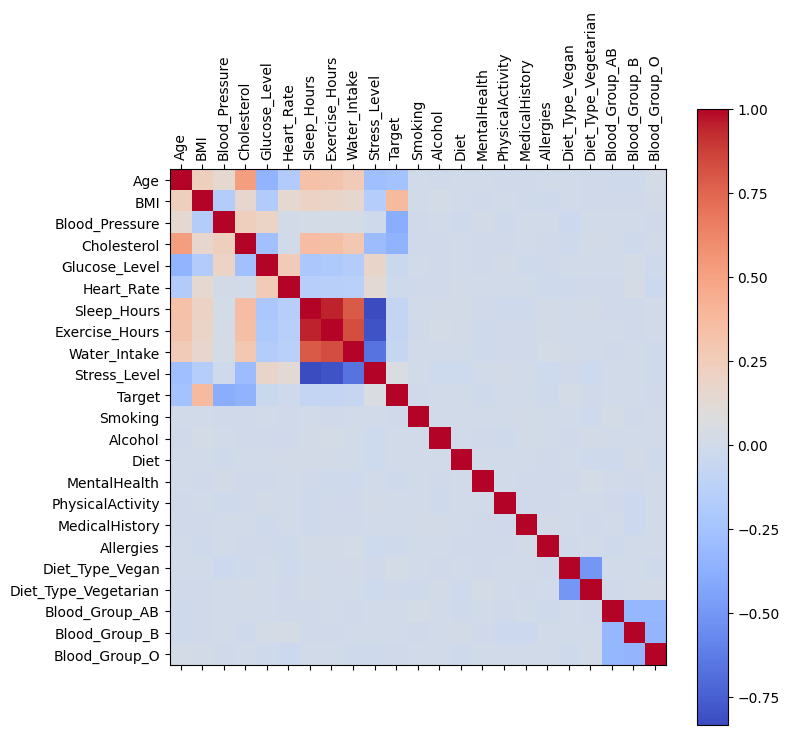

In [27]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 8))
cax = ax.matshow(corr, cmap='coolwarm')
fig.colorbar(cax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
plt.show()

1. Sleephours is highly correlated - exercise hours, water intake
2. Stress level are negatively correlated - Sleep Hours, Exercise hours, water intake
3. Diet type vegan is negatively correlated with diet type vegetarian
4. Target is positively correlated to BMI and negatively correlated to Age, blood pressure and cholestrol.
5. Blood groups are negatively correlated

(array([  11.,  108.,  466., 1042., 1616., 2991., 2348.,  764.,  115.,
          10.]),
 array([ 22. ,  42.3,  62.6,  82.9, 103.2, 123.5, 143.8, 164.1, 184.4,
        204.7, 225. ]),
 <BarContainer object of 10 artists>)

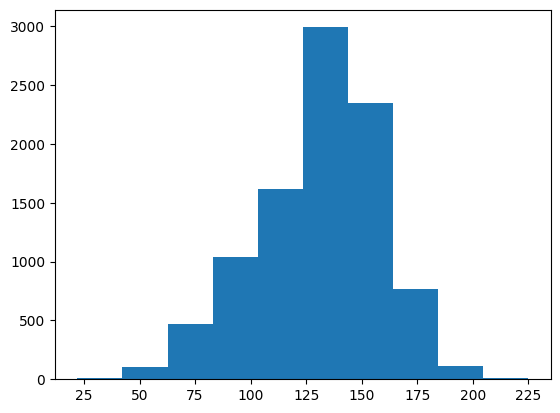

In [28]:
plt.hist(raw_df["Blood_Pressure"])

In [29]:
def get_segment_by_age_groups(col, reference_df):
    """Function takes reference_df as parameter instead of using global raw_df"""
    col_data = col.copy()
    col_by_age_median = reference_df.groupby("Age")[col.name].transform("median")
    col_data = col_data.fillna(col_by_age_median)

    # if any age group have all null values, then fill them by taking an overall mean
    col_data = col_data.fillna(col_data.mean())
    return col_data

### Imputing null values with the median value as per age segment
As no business logic was provided, and these, "Blood_Pressure", "Cholesterol", "Glucose_Level", features are correlated with age, implementing the logic accordingly

In [30]:
# Then apply with lambda to pass raw_df
raw_df_imputed = raw_df.copy()
raw_df_imputed[["Blood_Pressure", "Cholesterol", "Glucose_Level"]] = \
    raw_df_imputed[["Blood_Pressure", "Cholesterol", "Glucose_Level"]].apply(
        lambda col: get_segment_by_age_groups(col, raw_df_imputed)
    )

In [31]:
for col in raw_df_imputed.columns:
    print(col, "--", raw_df_imputed[col].isnull().sum())

Age -- 0
BMI -- 0
Blood_Pressure -- 0
Cholesterol -- 0
Glucose_Level -- 0
Heart_Rate -- 0
Sleep_Hours -- 0
Exercise_Hours -- 0
Water_Intake -- 0
Stress_Level -- 0
Target -- 0
Smoking -- 0
Alcohol -- 0
Diet -- 0
MentalHealth -- 0
PhysicalActivity -- 0
MedicalHistory -- 535
Allergies -- 521
Diet_Type_Vegan -- 0
Diet_Type_Vegetarian -- 0
Blood_Group_AB -- 0
Blood_Group_B -- 0
Blood_Group_O -- 0


### Imputing null values with zero
As no business logic was provided, we consider that these patients don't have any allergies or medicalhistory associated with them

In [32]:
raw_df_imputed["MedicalHistory"] = raw_df_imputed["MedicalHistory"].fillna(0)
raw_df_imputed["Allergies"] = raw_df_imputed["Allergies"].fillna(0)

In [33]:
for col in raw_df_imputed.columns:
    print(col, "--", raw_df_imputed[col].isnull().sum())

Age -- 0
BMI -- 0
Blood_Pressure -- 0
Cholesterol -- 0
Glucose_Level -- 0
Heart_Rate -- 0
Sleep_Hours -- 0
Exercise_Hours -- 0
Water_Intake -- 0
Stress_Level -- 0
Target -- 0
Smoking -- 0
Alcohol -- 0
Diet -- 0
MentalHealth -- 0
PhysicalActivity -- 0
MedicalHistory -- 0
Allergies -- 0
Diet_Type_Vegan -- 0
Diet_Type_Vegetarian -- 0
Blood_Group_AB -- 0
Blood_Group_B -- 0
Blood_Group_O -- 0


## Check for outliers
<< After thinking thoroughly, I don't think we should handle outliers, as these are important data points and we don't want to loose them.>> <br>
But still, for future reference, below is the code for handling outliers.

In [53]:
len(raw_df.columns)

23

In [54]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   10000 non-null  float64
 1   BMI                   10000 non-null  float64
 2   Blood_Pressure        9471 non-null   float64
 3   Cholesterol           9462 non-null   float64
 4   Glucose_Level         9486 non-null   float64
 5   Heart_Rate            10000 non-null  float64
 6   Sleep_Hours           10000 non-null  float64
 7   Exercise_Hours        10000 non-null  float64
 8   Water_Intake          10000 non-null  float64
 9   Stress_Level          10000 non-null  float64
 10  Target                10000 non-null  int64  
 11  Smoking               10000 non-null  int64  
 12  Alcohol               10000 non-null  int64  
 13  Diet                  10000 non-null  int64  
 14  MentalHealth          10000 non-null  int64  
 15  PhysicalActivity      10000 non

In [52]:
numerical_cols = raw_df_imputed.select_dtypes(include='number').columns

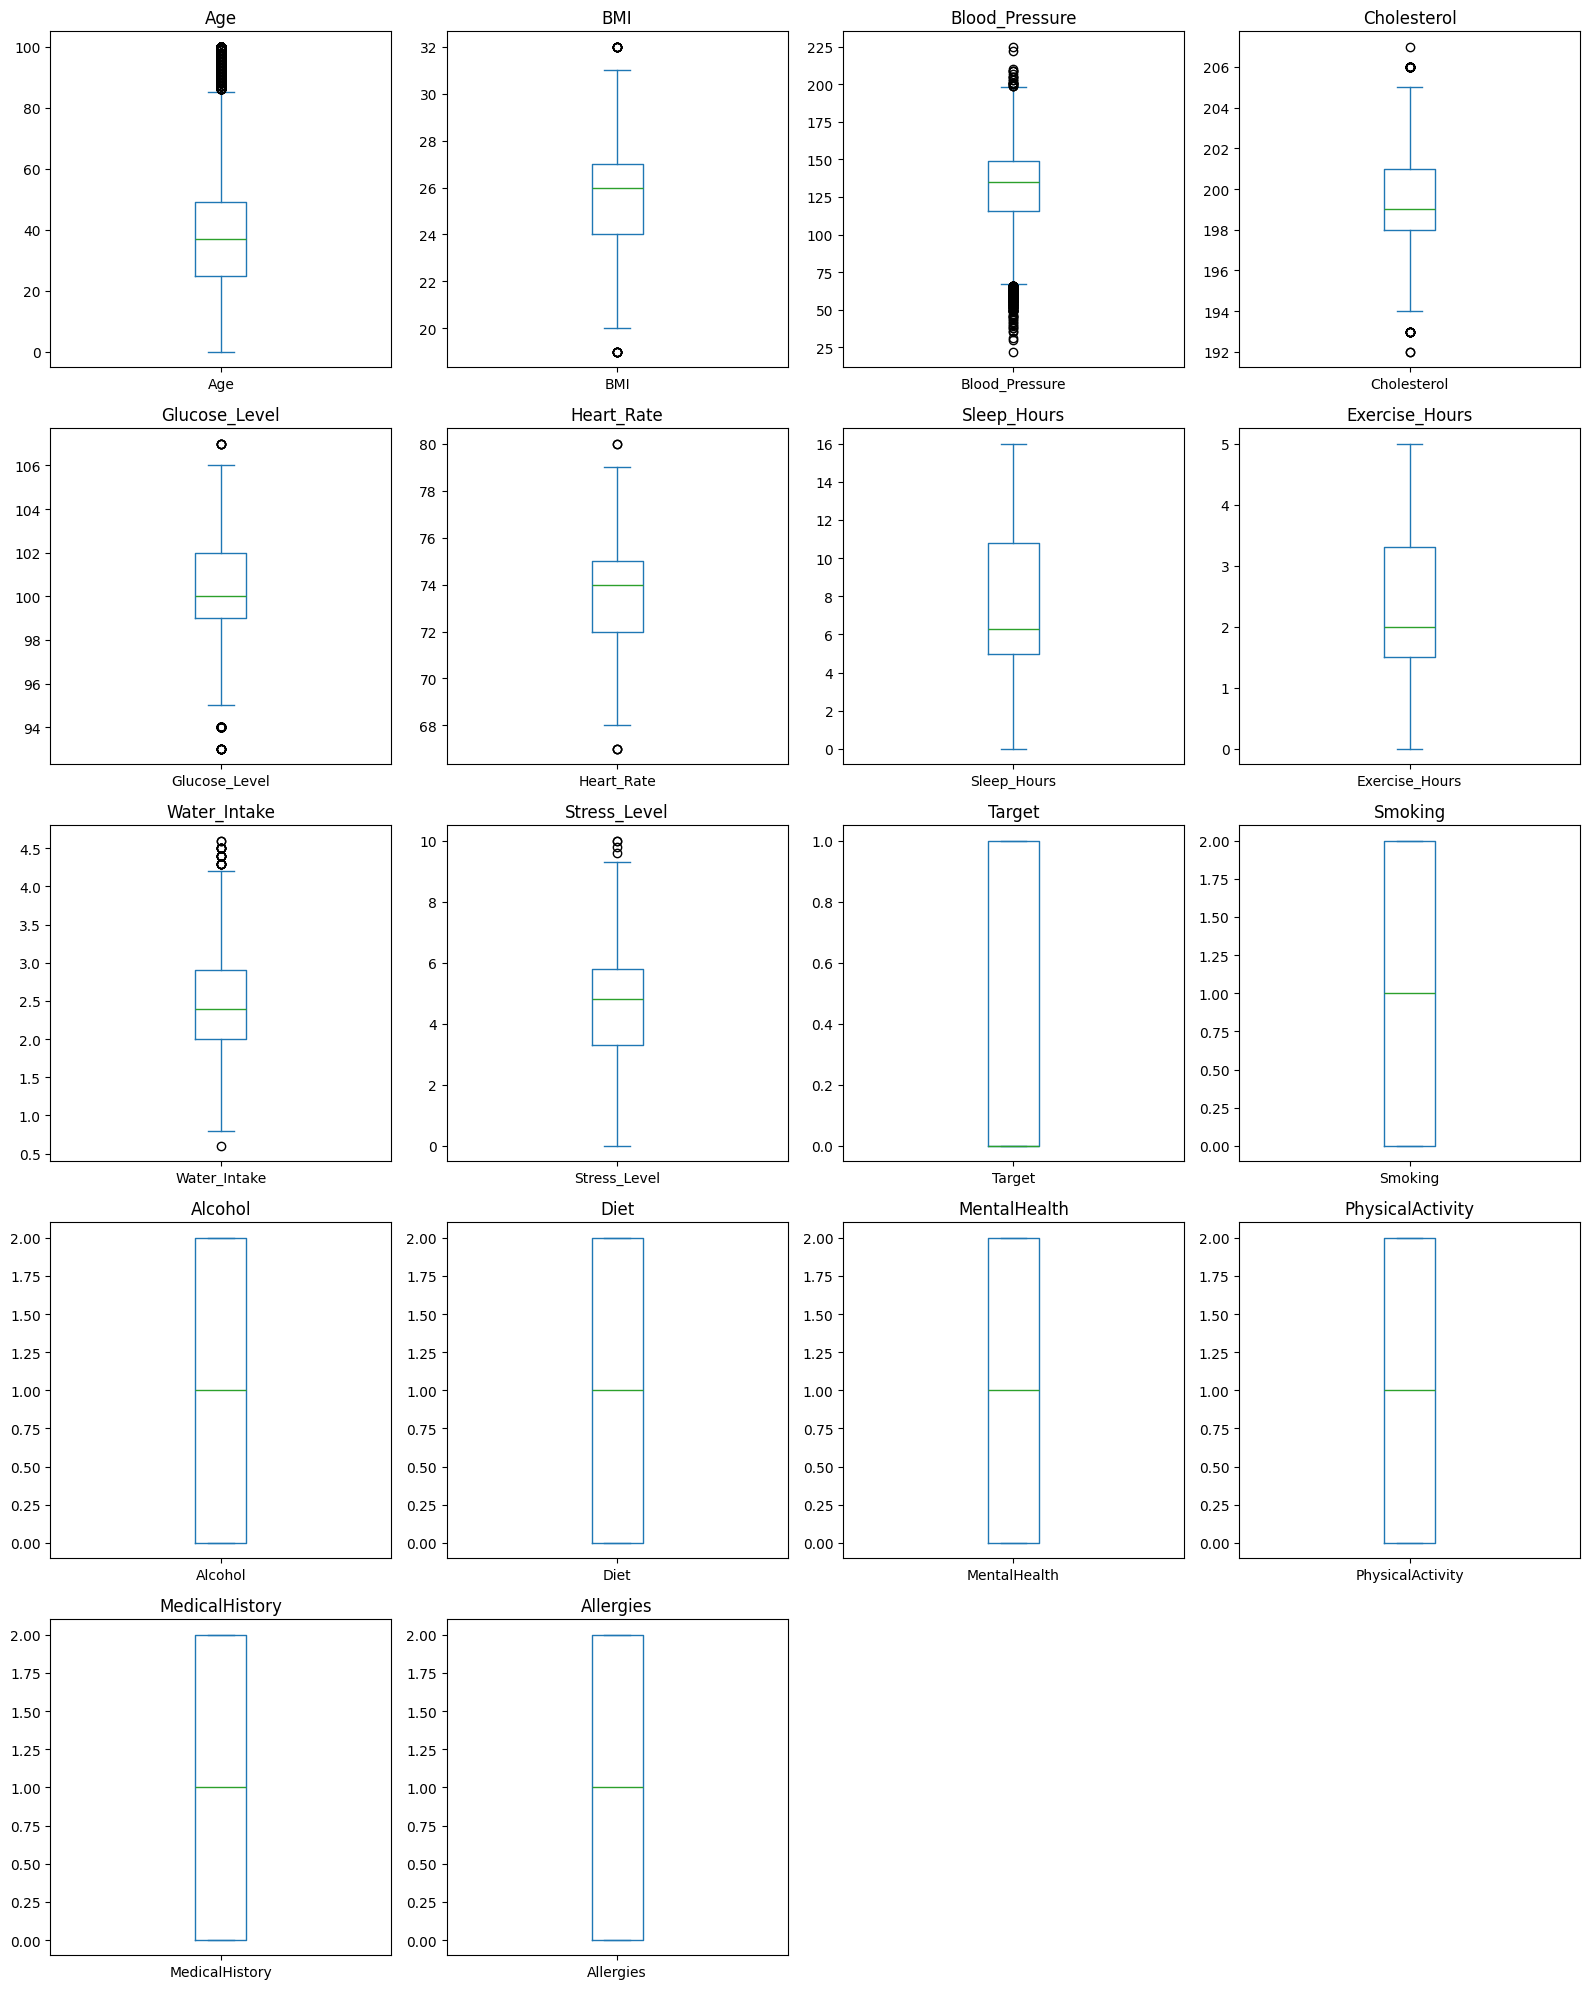

In [66]:
n_cols = 4 # no. of columns
len_num_cols = len(numerical_cols)
n_rows = math.ceil(len_num_cols / n_cols) # no. of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    raw_df_imputed[col].plot(kind='box', ax=axes[i], title=col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [63]:
Q1 = raw_df_imputed[numerical_cols].quantile(0.25)
Q3 = raw_df_imputed[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_df = ((raw_df_imputed[numerical_cols] < lower_bound) | 
            (raw_df_imputed[numerical_cols] > upper_bound))
print(outliers_df.sum())  # count of outliers per column

Age                 773
BMI                  17
Blood_Pressure      202
Cholesterol          36
Glucose_Level        58
Heart_Rate            5
Sleep_Hours           0
Exercise_Hours        0
Water_Intake         26
Stress_Level          4
Target                0
Smoking               0
Alcohol               0
Diet                  0
MentalHealth          0
PhysicalActivity      0
MedicalHistory        0
Allergies             0
dtype: int64


### Applying capping to preserve the data size
Anything below lower bound will be capped to it, and anything above upper bound will be capped to it respectively.

In [62]:
raw_df_clean = raw_df_imputed.copy()

raw_df_clean[numerical_cols] = raw_df_clean[numerical_cols].clip(
    lower=lower_bound, upper=upper_bound, axis=1
)

In [64]:
Q1 = raw_df_clean[numerical_cols].quantile(0.25)
Q3 = raw_df_clean[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_df = ((raw_df_clean[numerical_cols] < lower_bound) | 
            (raw_df_clean[numerical_cols] > upper_bound))
print(outliers_df.sum())  # count of outliers per column

Age                 0
BMI                 0
Blood_Pressure      0
Cholesterol         0
Glucose_Level       0
Heart_Rate          0
Sleep_Hours         0
Exercise_Hours      0
Water_Intake        0
Stress_Level        0
Target              0
Smoking             0
Alcohol             0
Diet                0
MentalHealth        0
PhysicalActivity    0
MedicalHistory      0
Allergies           0
dtype: int64


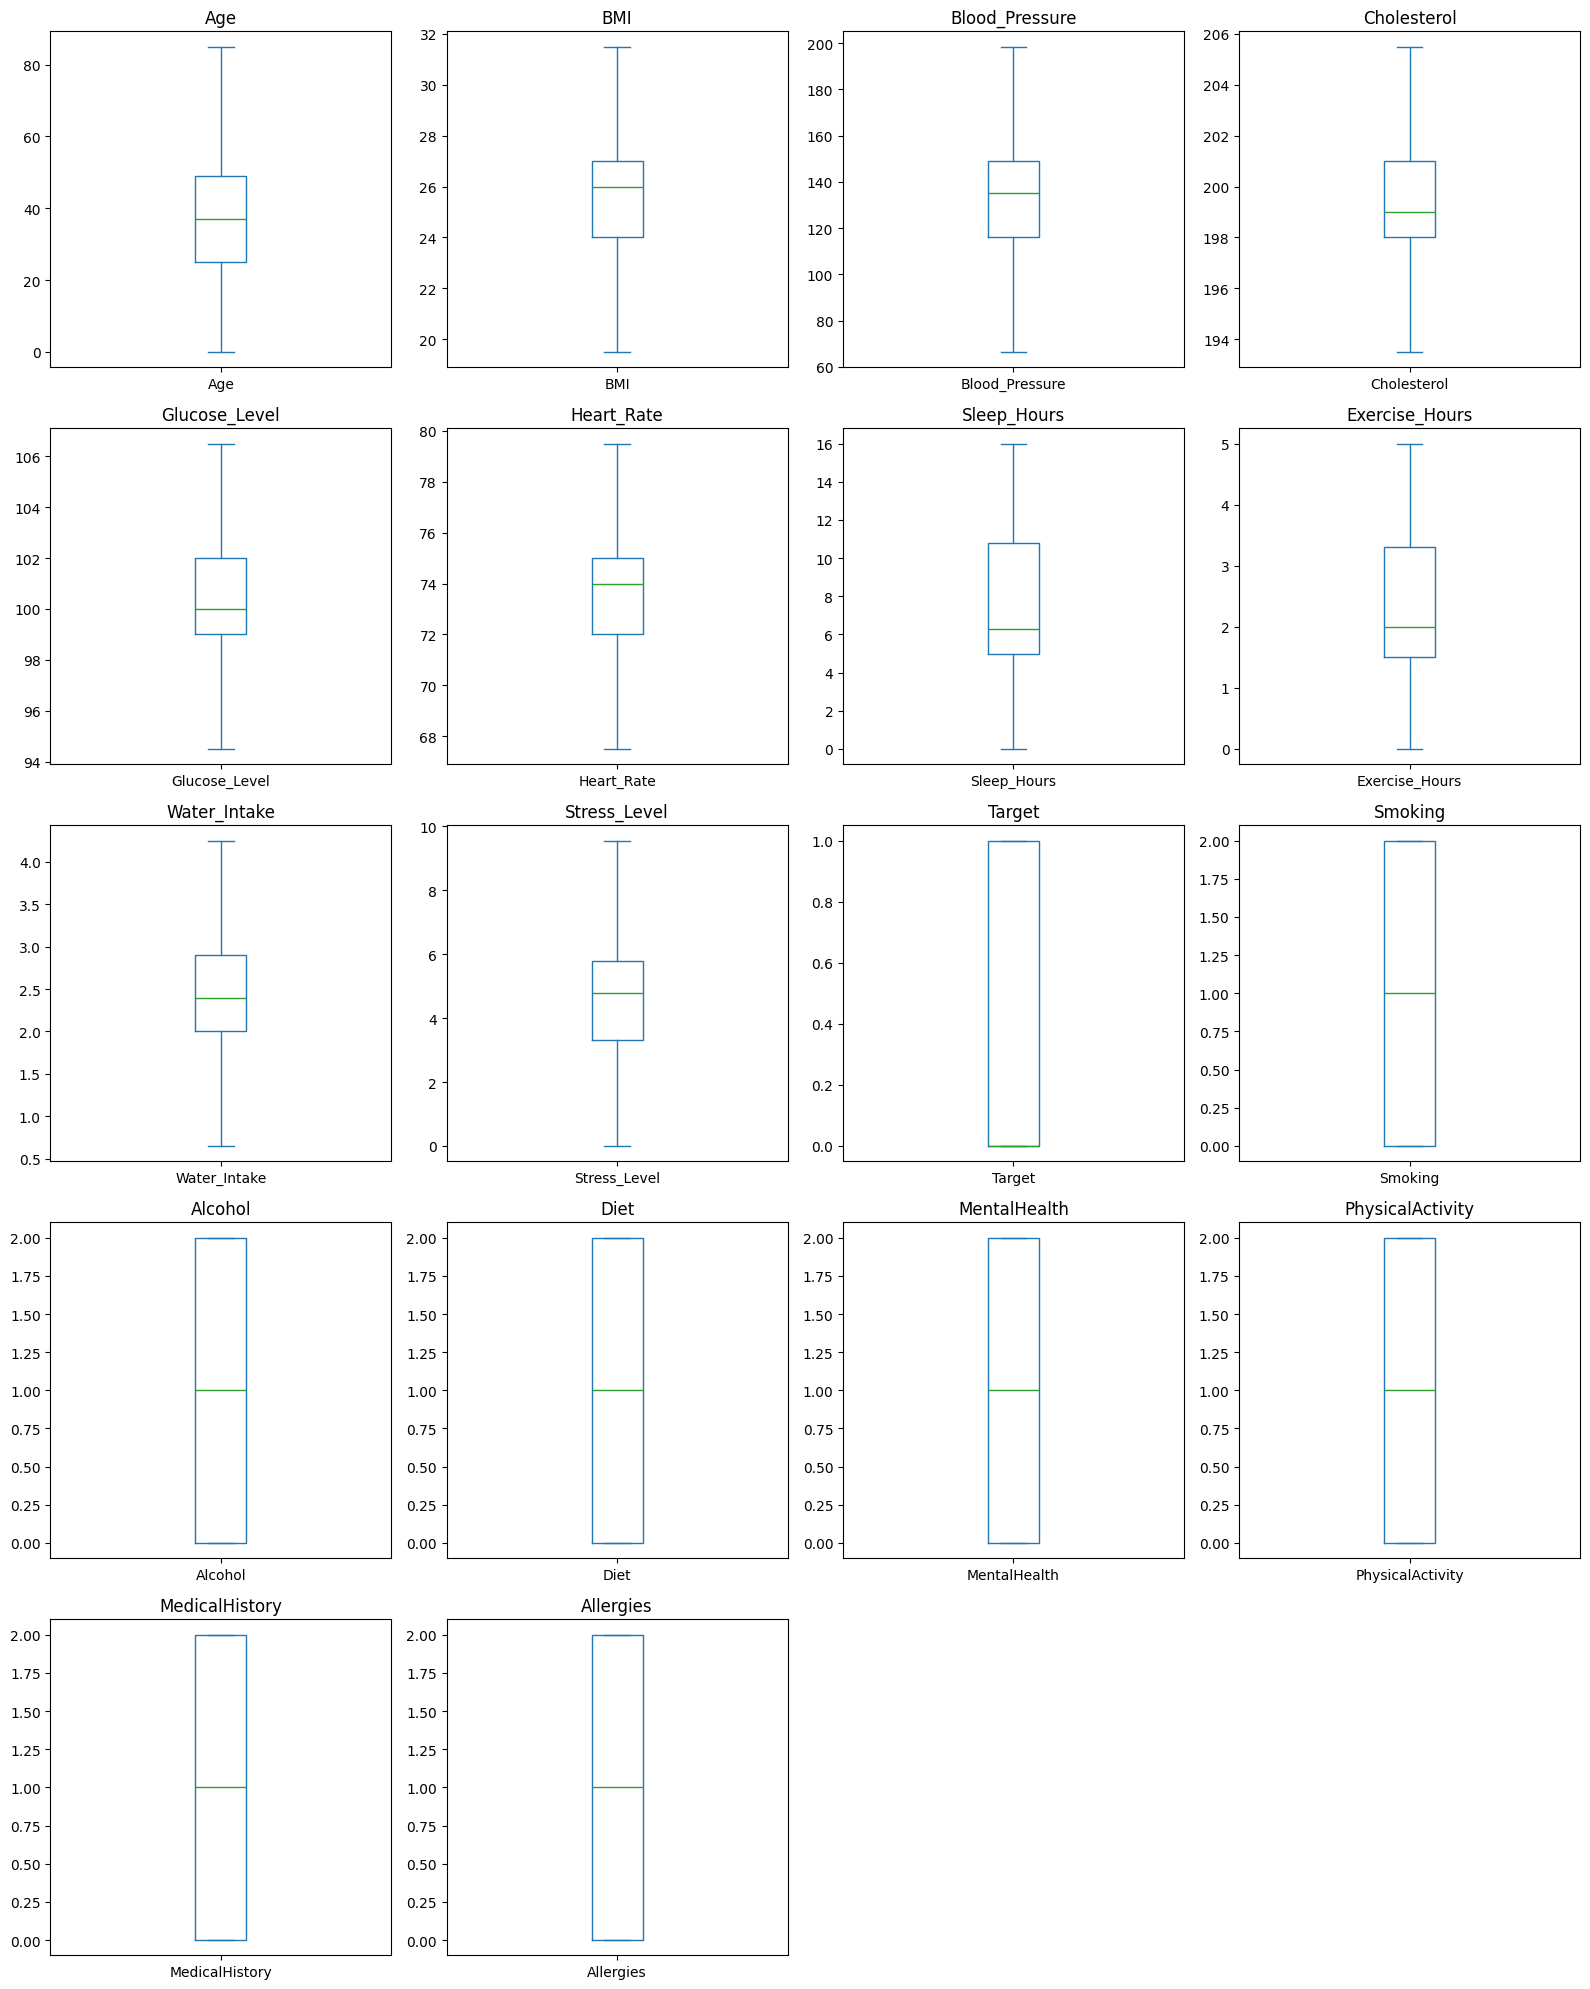

In [68]:
n_cols = 4 # no. of columns
len_num_cols = len(numerical_cols)
n_rows = math.ceil(len_num_cols / n_cols) # no. of rows

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    raw_df_clean[col].plot(kind='box', ax=axes[i], title=col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Checking for outliers in non-numeric columns

In [69]:
# For each boolean/categorical column
categorical_cols = raw_df_imputed.select_dtypes(include=['bool', 'object']).columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(raw_df_imputed[col].value_counts(normalize=True))  # shows percentages


Diet_Type_Vegan:
Diet_Type_Vegan
False    0.6693
True     0.3307
Name: proportion, dtype: float64

Diet_Type_Vegetarian:
Diet_Type_Vegetarian
False    0.664
True     0.336
Name: proportion, dtype: float64

Blood_Group_AB:
Blood_Group_AB
False    0.755
True     0.245
Name: proportion, dtype: float64

Blood_Group_B:
Blood_Group_B
False    0.7471
True     0.2529
Name: proportion, dtype: float64

Blood_Group_O:
Blood_Group_O
False    0.7462
True     0.2538
Name: proportion, dtype: float64


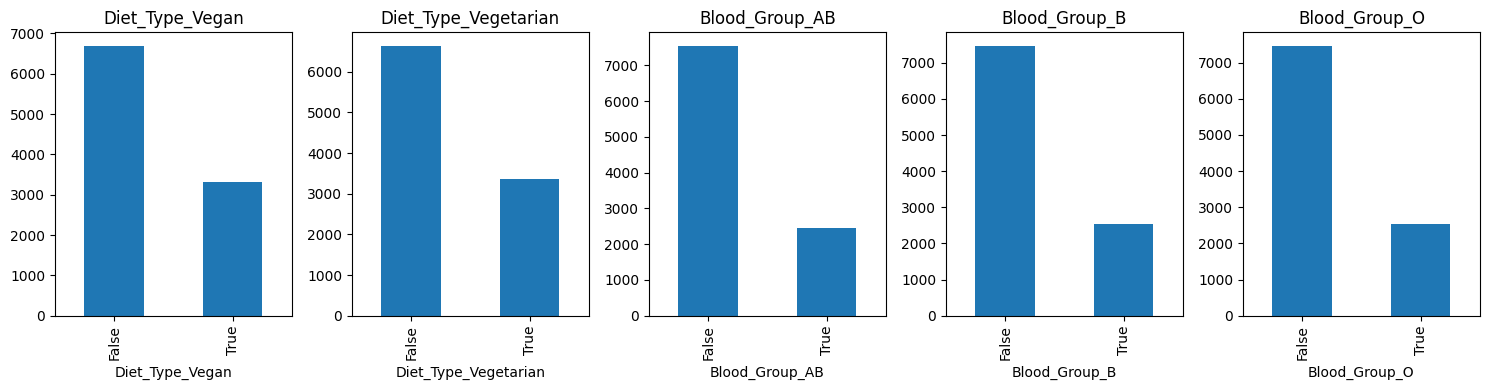

In [70]:
fig, axes = plt.subplots(1, len(categorical_cols), figsize=(15, 4))
for i, col in enumerate(categorical_cols):
    raw_df_imputed[col].value_counts().plot(kind='bar', ax=axes[i], title=col)
plt.tight_layout()
plt.show()

## Saving the preprocessed data

In [72]:
raw_df_imputed.to_csv("./data/preprocessed.csv", index=False)